============================================================
RANDOM FOREST ASSIGNMENT - GLASS DATASET
============================================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

============================================================
1. DATA OVERVIEW
============================================================

In [3]:
print("=" * 60)
print("1. DATA OVERVIEW")
print("=" * 60)

1. DATA OVERVIEW


In [4]:
# Load dataset
df = pd.read_excel("glass.xlsx", sheet_name="glass")
print(df.columns)

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='str')


In [5]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
        RI     Na    Mg    Al     Si     K    Ca   Ba   Fe  Type
0  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.0     1
1  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.0     1
2  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.0     1
3  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.0     1
4  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.0     1


In [6]:
print("\nShape of dataset:")
print(df.shape)


Shape of dataset:
(214, 10)


In [7]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']


In [8]:
print("\nData types:")
print(df.dtypes)


Data types:
RI      float64
Na      float64
Mg      float64
Al      float64
Si      float64
K       float64
Ca      float64
Ba      float64
Fe      float64
Type      int64
dtype: object


In [9]:
print("\nStatistical summary:")
print(df.describe())


Statistical summary:
               RI          Na          Mg          Al          Si           K  \
count  214.000000  214.000000  214.000000  214.000000  214.000000  214.000000   
mean     1.518365   13.407850    2.684533    1.444907   72.650935    0.497056   
std      0.003037    0.816604    1.442408    0.499270    0.774546    0.652192   
min      1.511150   10.730000    0.000000    0.290000   69.810000    0.000000   
25%      1.516522   12.907500    2.115000    1.190000   72.280000    0.122500   
50%      1.517680   13.300000    3.480000    1.360000   72.790000    0.555000   
75%      1.519157   13.825000    3.600000    1.630000   73.087500    0.610000   
max      1.533930   17.380000    4.490000    3.500000   75.410000    6.210000   

               Ca          Ba          Fe        Type  
count  214.000000  214.000000  214.000000  214.000000  
mean     8.956963    0.175047    0.057009    2.780374  
std      1.423153    0.497219    0.097439    2.103739  
min      5.430000    0.0

============================================================
2. EXPLORATORY DATA ANALYSIS (EDA)
============================================================

In [10]:
print("\n" + "=" * 60)
print("2. EXPLORATORY DATA ANALYSIS")
print("=" * 60)


2. EXPLORATORY DATA ANALYSIS


In [11]:
# Missing values
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64


In [12]:
print("\nTotal missing values:")
print(df.isnull().sum().sum())


Total missing values:
0


In [13]:
# Duplicate values
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())


Number of duplicate rows:
1


In [14]:
# Target class distribution
print("\nTarget class distribution:")
print(df["Type"].value_counts().sort_index())


Target class distribution:
Type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


In [15]:
# Check unique values
print("\nUnique values in each column:")
for column in df.columns:
    print(column, ":", df[column].nunique())


Unique values in each column:
RI : 178
Na : 142
Mg : 94
Al : 118
Si : 133
K : 65
Ca : 143
Ba : 34
Fe : 32
Type : 6


============================================================
3. OUTLIER DETECTION
============================================================

In [16]:
print("\n" + "=" * 60)
print("3. OUTLIER DETECTION")
print("=" * 60)


3. OUTLIER DETECTION


In [17]:
features = df.drop(columns=["Type"])

In [18]:
Q1 = features.quantile(0.25)
Q3 = features.quantile(0.75)
IQR = Q3 - Q1

In [19]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [20]:
outliers = ((features < lower_bound) |
            (features > upper_bound)).sum()

In [21]:
print("\nNumber of potential outliers:")
print(outliers)


Number of potential outliers:
RI    17
Na     7
Mg     0
Al    18
Si    12
K      7
Ca    26
Ba    38
Fe    12
dtype: int64


============================================================
4. DATA VISUALIZATION
============================================================

In [22]:
print("\n" + "=" * 60)
print("4. DATA VISUALIZATION")
print("=" * 60)


4. DATA VISUALIZATION


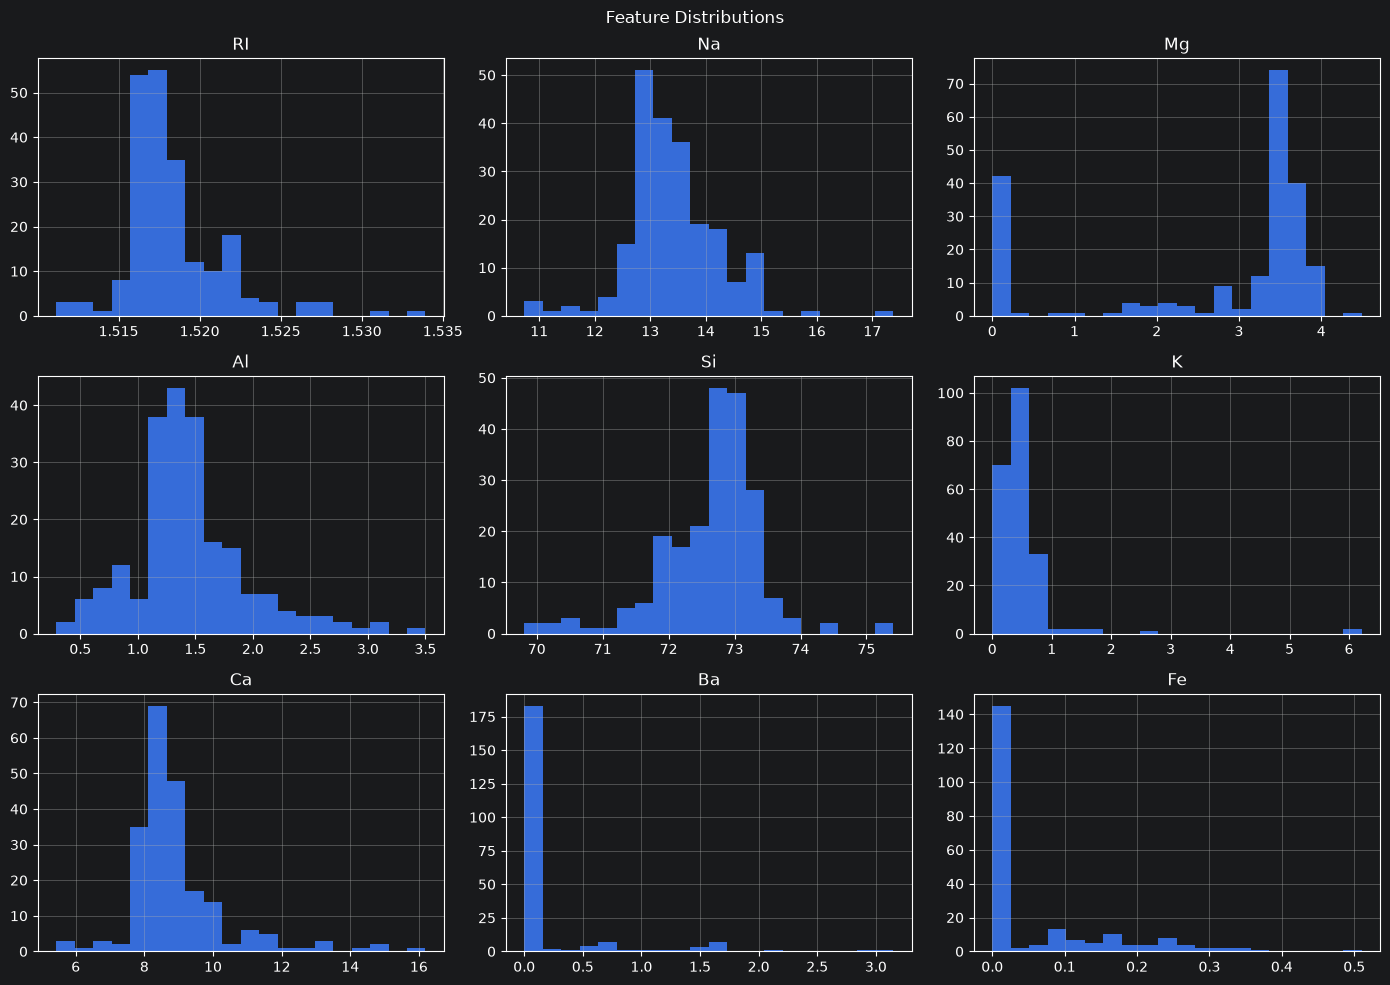

In [23]:
# Histograms
features.hist(figsize=(14, 10), bins=20)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

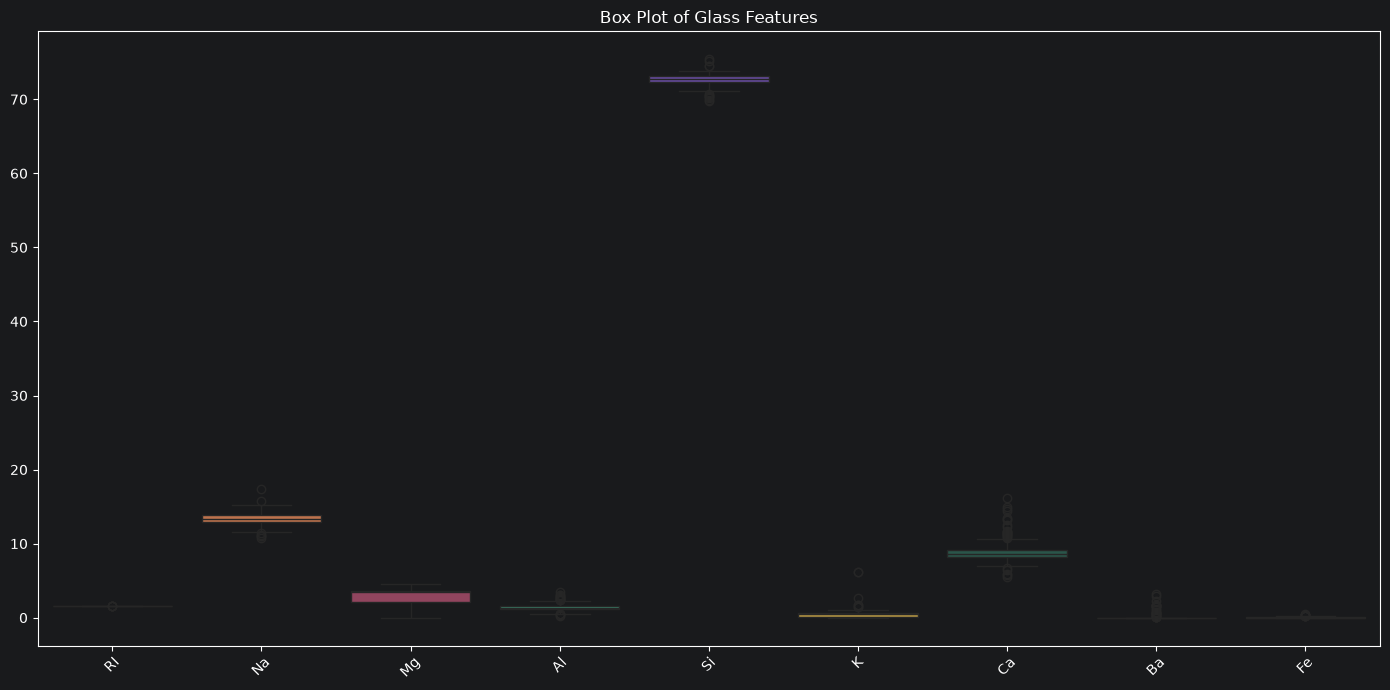

In [24]:
# Box plots
plt.figure(figsize=(14, 7))
sns.boxplot(data=features)
plt.title("Box Plot of Glass Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

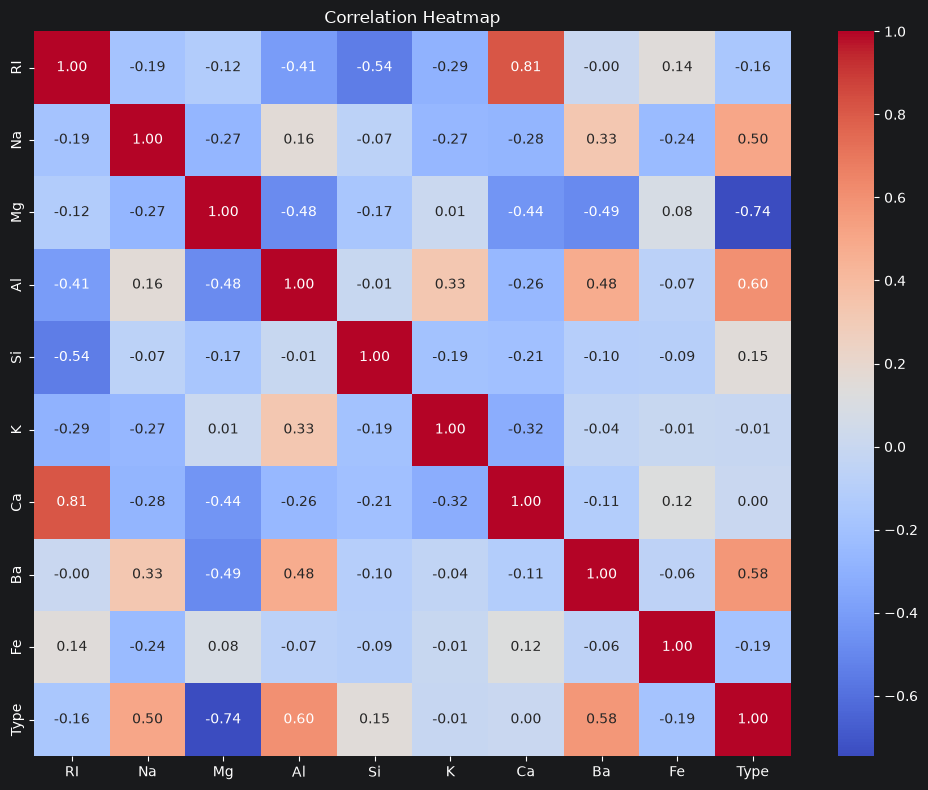

In [25]:
# Correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

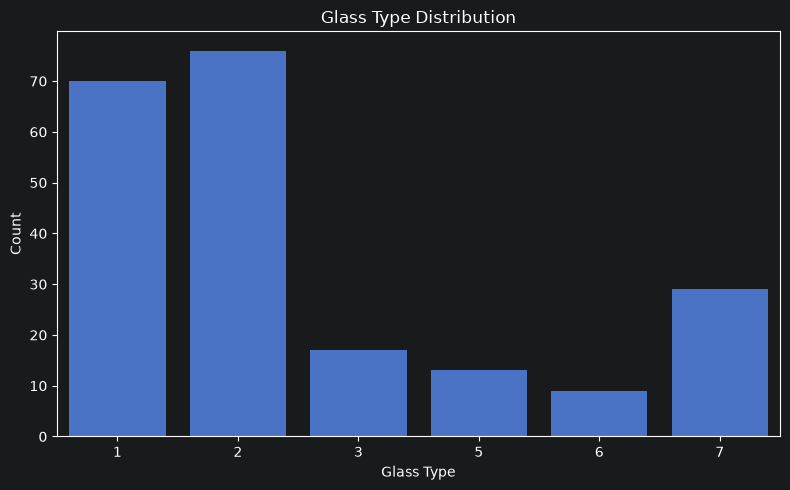

In [26]:
# Target class distribution
plt.figure(figsize=(8, 5))
sns.countplot(x="Type", data=df)
plt.title("Glass Type Distribution")
plt.xlabel("Glass Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

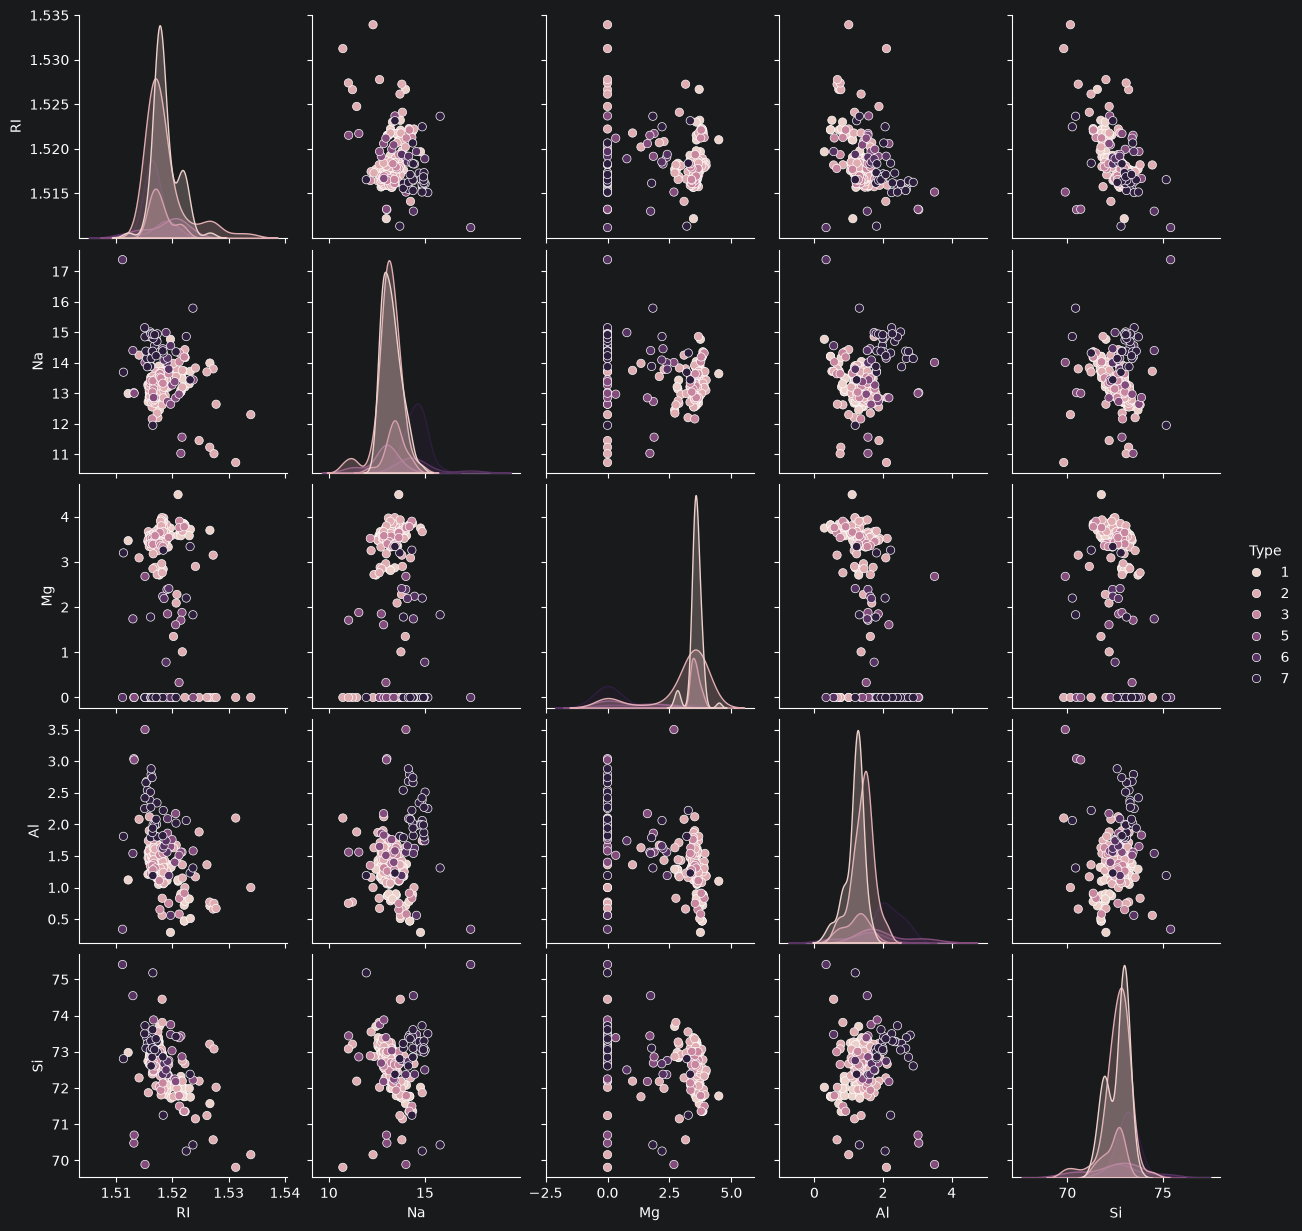

In [27]:
# Pairplot
sns.pairplot(
    df,
    hue="Type",
    vars=["RI", "Na", "Mg", "Al", "Si"]
)
plt.show()

============================================================
5. DATA PREPROCESSING
============================================================

In [28]:
print("\n" + "=" * 60)
print("5. DATA PREPROCESSING")
print("=" * 60)


5. DATA PREPROCESSING


In [29]:
# Separate features and target
X = df.drop(columns=["Type"])
y = df["Type"]

In [30]:
# Check categorical variables
categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

In [31]:
print("\nCategorical columns:")
print(categorical_columns)


Categorical columns:
[]


In [32]:
if len(categorical_columns) == 0:
    print("No categorical variables are present.")

No categorical variables are present.


In [33]:
# Missing value handling
imputer = SimpleImputer(strategy="median")

In [34]:
X_imputed = imputer.fit_transform(X)

In [35]:
print("\nMissing values handled using median imputation.")


Missing values handled using median imputation.


In [36]:
# Feature scaling
scaler = StandardScaler()

In [37]:
X_scaled = scaler.fit_transform(X_imputed)

In [38]:
print("Feature scaling completed using StandardScaler.")

Feature scaling completed using StandardScaler.


============================================================
6. TRAIN-TEST SPLIT
============================================================

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [40]:
print("\nTraining data shape:")
print(X_train.shape)


Training data shape:
(171, 9)


In [41]:
print("\nTesting data shape:")
print(X_test.shape)


Testing data shape:
(43, 9)


============================================================
7. RANDOM FOREST CLASSIFIER
============================================================

In [42]:
print("\n" + "=" * 60)
print("6. RANDOM FOREST MODEL")
print("=" * 60)


6. RANDOM FOREST MODEL


In [43]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

In [44]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [45]:
# Prediction
y_pred_rf = rf_model.predict(X_test)

In [46]:
# Evaluation
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)
rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)
rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted",
    zero_division=0
)

In [47]:
print("\nRandom Forest Results")
print("-" * 40)
print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")


Random Forest Results
----------------------------------------
Accuracy  : 0.7442
Precision : 0.8298
Recall    : 0.7442
F1 Score  : 0.7613


In [48]:
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_rf,
    zero_division=0
))


Classification Report:
              precision    recall  f1-score   support

           1       0.90      0.64      0.75        14
           2       0.83      0.67      0.74        15
           3       0.33      1.00      0.50         3
           5       0.75      1.00      0.86         3
           6       0.67      1.00      0.80         2
           7       1.00      0.83      0.91         6

    accuracy                           0.74        43
   macro avg       0.75      0.86      0.76        43
weighted avg       0.83      0.74      0.76        43



In [49]:
# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

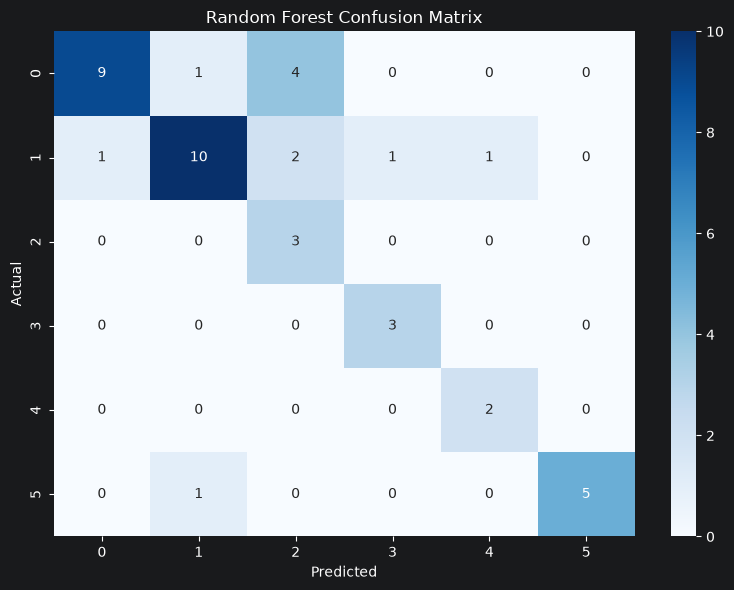

In [50]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

============================================================
8. FEATURE IMPORTANCE
============================================================

In [51]:
print("\n" + "=" * 60)
print("7. FEATURE IMPORTANCE")
print("=" * 60)


7. FEATURE IMPORTANCE


In [52]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

In [53]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

In [54]:
print("\nFeature Importance:")
print(importance)


Feature Importance:
  Feature  Importance
2      Mg    0.174470
5       K    0.140978
6      Ca    0.132543
1      Na    0.125914
0      RI    0.120026
3      Al    0.114778
4      Si    0.087577
7      Ba    0.083954
8      Fe    0.019759


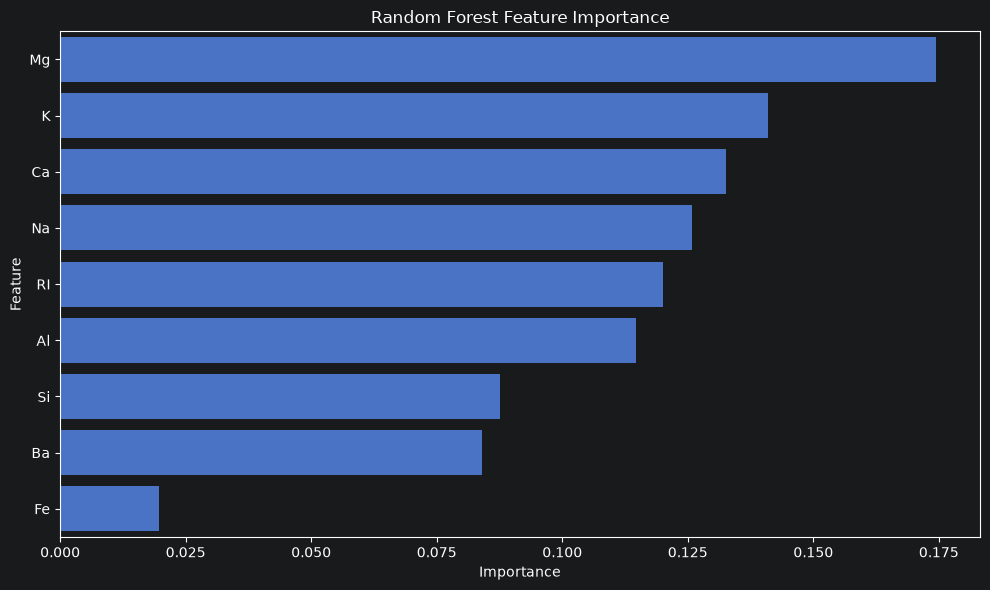

In [55]:
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

============================================================
9. BAGGING CLASSIFIER
============================================================

In [56]:
print("\n" + "=" * 60)
print("8. BAGGING METHOD")
print("=" * 60)


8. BAGGING METHOD


In [57]:
bagging_model = BaggingClassifier(
    n_estimators=200,
    random_state=42
)

In [58]:
bagging_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary <warm_start>`... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [59]:
y_pred_bagging = bagging_model.predict(X_test)

In [60]:
bagging_accuracy = accuracy_score(
    y_test,
    y_pred_bagging
)

In [61]:
bagging_precision = precision_score(
    y_test,
    y_pred_bagging,
    average="weighted",
    zero_division=0
)

In [62]:
bagging_recall = recall_score(
    y_test,
    y_pred_bagging,
    average="weighted",
    zero_division=0
)

In [63]:
bagging_f1 = f1_score(
    y_test,
    y_pred_bagging,
    average="weighted",
    zero_division=0
)

In [64]:
print("\nBagging Results")
print("-" * 40)
print(f"Accuracy  : {bagging_accuracy:.4f}")
print(f"Precision : {bagging_precision:.4f}")
print(f"Recall    : {bagging_recall:.4f}")
print(f"F1 Score  : {bagging_f1:.4f}")


Bagging Results
----------------------------------------
Accuracy  : 0.7442
Precision : 0.7445
Recall    : 0.7442
F1 Score  : 0.7408


============================================================
10. BOOSTING - ADABOOST
============================================================

In [65]:
print("\n" + "=" * 60)
print("9. BOOSTING METHOD")
print("=" * 60)


9. BOOSTING METHOD


In [66]:
boosting_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

In [67]:
boosting_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](6,)","[1,2,3,5,6,7]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](100,)","[0.53,0.4 ,0.59,...,0.55,0.66,0.61]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](100,)","[1.48,2.03,1.23,...,1.43,0.95,1.17]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1608637542), DecisionTreeC...te=1273642419), DecisionTreeC...te=1935803228), DecisionTreeC...ate=787846414), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](9,)","[0.05,0.07,0.58,...,0.09,0.02,0. ]"


In [68]:
y_pred_boosting = boosting_model.predict(X_test)

In [69]:
boosting_accuracy = accuracy_score(
    y_test,
    y_pred_boosting
)

In [70]:
boosting_precision = precision_score(
    y_test,
    y_pred_boosting,
    average="weighted",
    zero_division=0
)

In [71]:
boosting_recall = recall_score(
    y_test,
    y_pred_boosting,
    average="weighted",
    zero_division=0
)

In [72]:
boosting_f1 = f1_score(
    y_test,
    y_pred_boosting,
    average="weighted",
    zero_division=0
)

In [73]:
print("\nAdaBoost Results")
print("-" * 40)
print(f"Accuracy  : {boosting_accuracy:.4f}")
print(f"Precision : {boosting_precision:.4f}")
print(f"Recall    : {boosting_recall:.4f}")
print(f"F1 Score  : {boosting_f1:.4f}")


AdaBoost Results
----------------------------------------
Accuracy  : 0.3953
Precision : 0.4667
Recall    : 0.3953
F1 Score  : 0.3638


============================================================
11. BAGGING VS BOOSTING VS RANDOM FOREST
============================================================

In [74]:
print("\n" + "=" * 60)
print("10. MODEL COMPARISON")
print("=" * 60)


10. MODEL COMPARISON


In [75]:
comparison = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Bagging",
        "AdaBoost"
    ],
    "Accuracy": [
        rf_accuracy,
        bagging_accuracy,
        boosting_accuracy
    ],
    "Precision": [
        rf_precision,
        bagging_precision,
        boosting_precision
    ],
    "Recall": [
        rf_recall,
        bagging_recall,
        boosting_recall
    ],
    "F1 Score": [
        rf_f1,
        bagging_f1,
        boosting_f1
    ]
})

In [76]:
print("\nModel Comparison:")
print(comparison.to_string(index=False))


Model Comparison:
        Model  Accuracy  Precision   Recall  F1 Score
Random Forest  0.744186   0.829845 0.744186  0.761328
      Bagging  0.744186   0.744527 0.744186  0.740762
     AdaBoost  0.395349   0.466667 0.395349  0.363817


<Axes: xlabel='Model'>

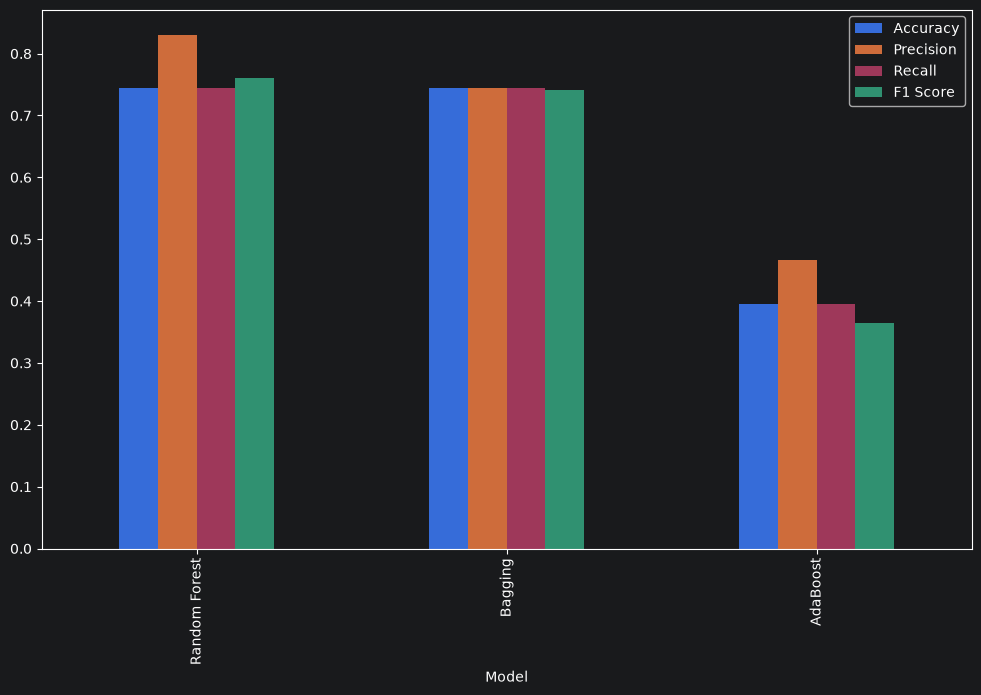

In [77]:
# Comparison graph
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(12, 7)
)

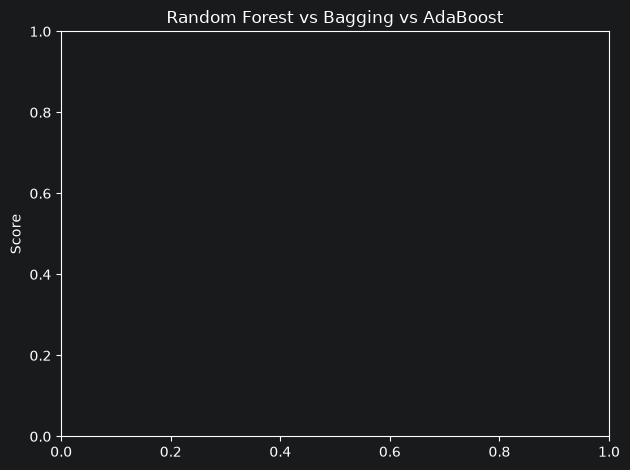

In [78]:
plt.title("Random Forest vs Bagging vs AdaBoost")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

============================================================
12. IMBALANCE HANDLING
============================================================

In [79]:
print("\n" + "=" * 60)
print("11. HANDLING IMBALANCED DATA")
print("=" * 60)


11. HANDLING IMBALANCED DATA


In [80]:
class_counts = y.value_counts().sort_index()

In [81]:
print("\nClass distribution:")
print(class_counts)


Class distribution:
Type
1    70
2    76
3    17
5    13
6     9
7    29
Name: count, dtype: int64


In [82]:
print(
    "\nRandom Forest was implemented with "
    "class_weight='balanced' to give greater importance "
    "to minority classes."
)


Random Forest was implemented with class_weight='balanced' to give greater importance to minority classes.


In [83]:
print(
    "\nStratified train-test split was also used to preserve "
    "the class distribution in training and testing data."
)


Stratified train-test split was also used to preserve the class distribution in training and testing data.


============================================================
13. INTERVIEW QUESTIONS
============================================================

In [84]:
print("\n" + "=" * 60)
print("12. INTERVIEW QUESTIONS")
print("=" * 60)


12. INTERVIEW QUESTIONS


In [85]:
print("""
Q1. What is the difference between Bagging and Boosting?

Answer:
Bagging stands for Bootstrap Aggregating. It creates multiple
models independently using different bootstrap samples of the
training data and combines their predictions. Random Forest is
an example of a bagging-based ensemble method.

Boosting creates models sequentially. Each new model focuses
more on the errors made by the previous models. AdaBoost and
Gradient Boosting are examples of boosting methods.

The main difference is that Bagging trains models independently,
while Boosting trains models sequentially. Bagging mainly reduces
variance, whereas Boosting mainly focuses on reducing bias and
improving predictive performance.


Q2. How can you handle imbalanced data in a classification problem?

Answer:
Imbalanced data occurs when some classes have significantly more
observations than other classes.

Common techniques for handling imbalance include:

1. Oversampling the minority class.
2. Undersampling the majority class.
3. Using SMOTE to generate synthetic minority samples.
4. Using class weights in machine learning models.
5. Using evaluation metrics such as precision, recall and F1-score
   instead of relying only on accuracy.

In this assignment, class_weight='balanced' was used in the
Random Forest model. Stratified train-test splitting was also
used so that the class distribution was maintained in both
training and testing datasets.
""")


Q1. What is the difference between Bagging and Boosting?

Answer:
Bagging stands for Bootstrap Aggregating. It creates multiple
models independently using different bootstrap samples of the
training data and combines their predictions. Random Forest is
an example of a bagging-based ensemble method.

Boosting creates models sequentially. Each new model focuses
more on the errors made by the previous models. AdaBoost and
Gradient Boosting are examples of boosting methods.

The main difference is that Bagging trains models independently,
while Boosting trains models sequentially. Bagging mainly reduces
variance, whereas Boosting mainly focuses on reducing bias and
improving predictive performance.


Q2. How can you handle imbalanced data in a classification problem?

Answer:
Imbalanced data occurs when some classes have significantly more
observations than other classes.

Common techniques for handling imbalance include:

1. Oversampling the minority class.
2. Undersampling the majority 

In [86]:
print("\n" + "=" * 60)
print("RANDOM FOREST ASSIGNMENT COMPLETED")
print("=" * 60)


RANDOM FOREST ASSIGNMENT COMPLETED
